# 基于 RNN 实现的古诗生成实验报告

**实验任务：** 使用 RNN 实现中文古诗生成。  
**生成要求：** 以“明月”为起始词，生成固定格式古诗，并加入叠字位置约束与押韵约束。  
**主要模型：** 字符级 LSTM 语言模型。  
**主要流程：** 数据读取与清洗 → 字符表构建 → 滑动窗口样本构造 → 模型训练 → 自回归生成 → 形式约束控制。约束控制。

## 1 实验目的

本实验以中文古诗文本为研究对象，完成基于循环神经网络的古诗自动生成任标是使用 PyTorch 构建字符级 RNN / GRU / LSTM 语言模型，使模型能够根据给定起始词“明月”生成固定格式的古诗，例如七言绝句或五言绝句。

通过本次实验，主要掌握以下内容：

1. 了解自然语言处理中字符级语言模型的基本思想；
2. 掌握古诗文本数据的读取、清洗和字符表构建方法；
3. 掌握基于滑动窗口的序列样本构造方式；
4. 掌握 `Embedding -> RNN/LSTM/GRU -> Linear` 的序列生成模型结构；
5. 掌握使用交叉熵损失函数训练语言模型的方法；
6. 掌握自回归文本生成的基本流程；
7. 在生成阶段加入叠字位置约束与押韵约束，使生成结果更符合古诗形式。

## 2 数据集与预处理

### 2.1 数据集介绍

本实验使用的古诗数据来源于 `chinese-poetry` 数据集中的宋诗 JSON 文件，主要包括：

```text
poet.song.40000.json
poet.song.41000.json
poet.song.42000.json
poet.song.43000.json
```

每条数据通常包含作者、标题、诗句内容等字段，其中与本实验最相关的是 `paragraphs` 字段。该字段以列表形式保存一首诗中的若干句诗。

由于原始宋诗数据中诗歌格式并不完全统一，既包含绝句，也包含律诗、长诗和其他不规则文本。如果只筛选严格的七言绝句，可能会导致可用数据数量过少，进而影响模型训练效果。因此，本实验没有强行要求训练数据必须全部为严格七言绝句，而是采用字符级语言模型的方式，将清洗后的古诗文本作为连续字符序列进行训练。

In [ ]:
import os
import re
import json
import random
import argparse
from typing import List, Dict, Tuple, Optional

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

import matplotlib.pyplot as plt

# 加入押韵判断
try:
    from pypinyin import lazy_pinyin, Style
    HAS_PYPINYIN = True
except ImportError:
    HAS_PYPINYIN = False

### 2.2 数据清洗方法

为了让模型专注于学习汉字之间的连接关系，实验中只保留中文汉字，不让模型学习标点符号。标点符号在生成阶段由程序根据五言或七言格式自动插入。可以减少无关符号干扰，让模型主要学习汉字。制诗歌格式。

In [ ]:

# 固定随机种子
def set_seed(seed: int = 42):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def is_chinese_char(ch: str) -> bool:
    return "\u4e00" <= ch <= "\u9fff"

# 只保留汉字，在后面生成阶段再插入标点
def clean_poem_text(text: str) -> str:
    return "".join([ch for ch in text if is_chinese_char(ch)])

# 读取数据集，不强行筛选绝句，而是清洗后作为连续字符语料。
def load_json_poems(data_dir: str, min_len: int = 20) -> List[str]:
    json_files = []

    for name in os.listdir(data_dir):
        if name.endswith(".json") and (
            name.startswith("poet.song") or name.startswith("poet.tang")
        ):
            json_files.append(os.path.join(data_dir, name))

    json_files = sorted(json_files)

    if len(json_files) == 0:
        raise FileNotFoundError(
            f"在 {data_dir} 中没有找到 poet.song*.json 或 poet.tang*.json 文件。"
        )

    print("使用数据文件：")
    for f in json_files:
        print("  ", f)

    poems = []
    # 读取每个文件
    for file_path in json_files:
        with open(file_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        for item in data:
            paragraphs = item.get("paragraphs", [])
            if not isinstance(paragraphs, list):
                continue

            raw_text = "".join(paragraphs)
            clean_text = clean_poem_text(raw_text)
            # 只保留长度足够的诗词
            if len(clean_text) >= min_len:
                poems.append(clean_text)

    poems = sorted(list(set(poems)))

    if len(poems) == 0:
        raise ValueError("没有得到可用诗歌，请检查 json 文件内容。\n")

    print("样例：\n")
    for p in poems[:5]:
        print(p[:80])

    return poems

### 2.3 字符表构建

由于本实验采用字符级建模，因此每个汉字都被视为一个基本 token。首先统计训练语料中出现过的所有汉字，然后为每个汉字分配唯一编号，同时，词表中加入两个特殊符号：

```text
<PAD>：填充符号，保留备用；
<UNK>：未知字符，用于处理词表中没有出现过的字符。
```符。
```

In [ ]:
# 创建字符表，统计所有出现过的汉字
def build_vocab(
    poems: List[str],
    min_freq: int = 1,
) -> Tuple[Dict[str, int], Dict[int, str], List[str]]:
    freq = {}

    for poem in poems:
        for ch in poem:
            freq[ch] = freq.get(ch, 0) + 1
    # 过滤低频的字
    chars = [ch for ch, c in freq.items() if c >= min_freq]
    chars = sorted(chars)

    vocab = ["<PAD>", "<UNK>"] + chars

    char2idx = {ch: i for i, ch in enumerate(vocab)}
    idx2char = {i: ch for ch, i in char2idx.items()}

    print(f"\n词表大小：{len(vocab)}")

    return char2idx, idx2char, vocab

# 将诗歌文本转换为索引序列
def poems_to_sequences(
    poems: List[str],
    char2idx: Dict[str, int],
) -> List[List[int]]:
    unk_idx = char2idx["<UNK>"]
    sequences = []

    for poem in poems:
        seq = [char2idx.get(ch, unk_idx) for ch in poem]
        if len(seq) > 1:
            sequences.append(seq)

    return sequences


## 3 实验设置

## 3.1 训练样本构造

本实验采用滑动窗口方式构造训练样本。对于一段连续的古诗文本，设定固定序列长度 `seq_len`，输入序列为当前位置开始的连续 `seq_len` 个字符，标签序列则是向后移动一位的 `seq_len` 个字

例如，对于文本：

```text
明月松间照清泉石上流
```

如果设定 `seq_len = 5`，则可以构造样本：

```text
输入：明 月 松 间 照
标签：月 松 间 照 清
```

这样模型在每一个时间步都需要根据当前及之前的信息预测下一个汉字。

In [ ]:
# 滑动窗口训练样本，序列预测
class PoetryDataset(Dataset):
    def __init__(
        self,
        sequences: List[List[int]],
        seq_len: int = 32,
        stride: int = 1, # 默认每次移动一个字，样本数量足够
    ):
        self.seq_len = seq_len
        self.stride = stride
        self.data = []

        for seq in sequences:
            if len(seq) <= seq_len:
                continue

            for i in range(0, len(seq) - seq_len, stride):
                x = seq[i:i + seq_len]
                y = seq[i + 1:i + 1 + seq_len]
                self.data.append((x, y))

        if len(self.data) == 0:
            raise ValueError(
                "没有构造出训练样本，减小 --seq_len。\n"
            )

        print(f"滑动窗口训练样本数：{len(self.data)}\n")
        print(f"seq_len = {seq_len}, stride = {stride}")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x, y = self.data[idx]
        return torch.LongTensor(x), torch.LongTensor(y)

### 3.2 网络结构

本实验中实现了三种可选循环神经网络结构：RNN、GRU 和 LSTM。

由于考虑到普通 RNN 在处理较长序列时容易出现梯度消失问题，本实验默认使用 LSTM。LSTM 通过引入门控结构，可以更稳定地建模较长模型首先通过 Embedding 层将汉字编号映射为稠密向量，然后通过两层 LSTM 建模字符序列中的上下文依赖关系，最后通过 Linear 层将每个时间步的隐藏状态转换为词表大小的预测向量。训练时，模型学习根据前面的字符预测下一个字符；生成时，模型以“明月”为起始输入，通过自回归方式逐字生成完整诗句。剪。将汉字编号映射为稠密向量，然后通过两层 LSTM 建模字符序列中的上下文依赖关系，最后通过 Linear 层将每个时间步的隐藏状态转换为词表大小的预测向量。训练时，模型学习根据前面的字符预测下一个字符；生成时，模型以“明月”为起始输入，通过自回归方式逐字生成完整诗句。

模型由三部分组成：

```text
Embedding 层
RNN / GRU / LSTM 层> 全连接层 -> 下一个字符概率分布
```

In [ ]:
# 模型结构，字符编号 → Embedding → RNN/LSTM/GRU → Linear → 每个字的概率分布
class PoetryRNNModel(nn.Module):

    def __init__(
        self,
        vocab_size: int,
        embedding_dim: int = 256,
        hidden_size: int = 512,
        num_layers: int = 2,
        model_type: str = "lstm",
        dropout: float = 0.2,
    ):
        super().__init__()

        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.model_type = model_type.lower()
        # 把一个字的编号转换成一个向量
        self.embed = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
        )

        rnn_dropout = dropout if num_layers > 1 else 0.0

        if self.model_type == "rnn":
            self.rnn = nn.RNN(
                input_size=embedding_dim,
                hidden_size=hidden_size,
                num_layers=num_layers,
                nonlinearity="tanh",
                dropout=rnn_dropout,
                batch_first=False,
            )
        elif self.model_type == "gru":
            self.rnn = nn.GRU(
                input_size=embedding_dim,
                hidden_size=hidden_size,
                num_layers=num_layers,
                dropout=rnn_dropout,
                batch_first=False,
            )
        elif self.model_type == "lstm":
            self.rnn = nn.LSTM(
                input_size=embedding_dim,
                hidden_size=hidden_size,
                num_layers=num_layers,
                dropout=rnn_dropout,
                batch_first=False,
            )
        else:
            raise ValueError("model_type 只能是 rnn / gru / lstm")

        self.linear = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        emb = self.embed(x)
        output, hidden = self.rnn(emb, hidden)
        logits = self.linear(output)
        return logits, hidden

### 3.3 训练方法

本实验的训练目标是“根据当前字符序列预测下一个字符序列”，本质上是一个多分类任务。在每个时间步，模型都需要从整个字符表中选择正确的下一个字符。因此，本实验采用交叉熵损失函数，优化器采用 Adam，考虑到循环神经网络训练过程中可能出现梯度爆炸问题，因此加入梯度裁剪。max_norm=5.0)
```.0)
```

In [ ]:
# 训练函数
def train_one_epoch(
    model: nn.Module,
    dataloader: DataLoader,
    optimizer,
    loss_fn,
    device,
    grad_clip: float = 5.0,
    log_interval: int = 100,
    epoch: int = 1,
    total_epochs: int = 1,
) -> float:
    model.train()

    total_loss = 0.0
    total_batches = 0

    for batch_idx, (x, y) in enumerate(dataloader, start=1):
        x = x.to(device)
        y = y.to(device)

        # RNN 输入：[seq_len, batch]
        x = x.transpose(0, 1)

        optimizer.zero_grad()
        # 前向传播
        logits, _ = model(x)

        logits_for_loss = logits.transpose(0, 1).transpose(1, 2)
        # 计算 loss
        loss = loss_fn(logits_for_loss, y)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=grad_clip,
        )
        # 反向传播和梯度裁剪，防止梯度爆炸
        optimizer.step()

        total_loss += loss.item()
        total_batches += 1

        if batch_idx % log_interval == 0:
            print(
                f"Epoch [{epoch}/{total_epochs}], "
                f"Step [{batch_idx}/{len(dataloader)}], "
                f"Loss: {loss.item():.4f}"
            )

    avg_loss = total_loss / max(total_batches, 1)
    return avg_loss


### 3.4 生成阶段的约束设计

为了让生成结果更符合古诗形式，本实验在基础自回归生成的基础上加入两个约束。

#### 3.4.1 叠字位置约束

在模型自由生成时，可能会出现无意义的连续重复字符，例如：

```text
明月月山山水水
```

因此，本实验规定：

```text
每句诗中，只有第 3-4 个字或第 6-7 个字允许出现叠字。字或第 6-7 个字允许出现叠字。
```

In [ ]:
# 加叠字位置约束，防止生成的诗词明显不通顺
def is_repeat_allowed(
    current_line_chars: List[str],
    candidate_char: str,
    line_length: int,
) -> bool:
    if len(current_line_chars) == 0:
        return True

    prev_char = current_line_chars[-1]

    # 不是叠字
    if candidate_char != prev_char:
        return True

    # 当前候选字在句内的位置
    current_pos = len(current_line_chars) + 1
    prev_pos = current_pos - 1

    # 位置约束
    if prev_pos == 3 and current_pos == 4:
        return True
    if prev_pos == 6 and current_pos == 7:
        return True

    return False

#### 3.4.2 押韵约束

七言绝句通常要求偶数句押韵，因此本实验设计了一个简化的押韵约束：

```text
第 2 句最后一个字作为韵脚；
第 4 句最后一个字必须与第 2 句最后一个字押韵。
```

本实验使用现代汉语拼音韵母进行近似判断。为了让押韵判断更灵活，实验中进一步将相近韵母归并。“间”也可以被视为押韵。

In [ ]:
# 获取汉字的拼音韵母，用于押韵
def get_pinyin_final(ch: str) -> str:

    if not HAS_PYPINYIN:
        return ""

    if not is_chinese_char(ch):
        return ""

    try:
        finals = lazy_pinyin(ch, style=Style.FINALS, strict=False)
        if len(finals) == 0:
            return ""
        return finals[0]
    except Exception:
        return ""

# 判断两个字是否押韵
def normalize_final(final: str) -> str:
    if final is None:
        return ""

    final = final.lower().strip()

    final = final.replace("ü", "v")

    rhyme_groups = {
        # an 韵
        "an": {"an", "ian", "uan", "van"},

        # ang 韵
        "ang": {"ang", "iang", "uang"},

        # en/in/un/ün 可视为近韵
        "en": {"en", "in", "un", "vn"},

        # eng/ing/ong/iong 可视为近韵
        "eng": {"eng", "ing", "ong", "iong"},

        # ai/uai
        "ai": {"ai", "uai"},

        # ei/ui/uei
        "ei": {"ei", "ui", "uei"},

        # ao/iao
        "ao": {"ao", "iao"},

        # ou/iu/iou
        "ou": {"ou", "iu", "iou"},

        # a/ia/ua
        "a": {"a", "ia", "ua"},

        # o/uo
        "o": {"o", "uo"},

        # e/ie/ve/ue
        "e": {"e", "ie", "ve", "ue"},

        # er 单独一类
        "er": {"er"},
    }

    for group_name, finals in rhyme_groups.items():
        if final in finals:
            return group_name

    return final


def same_rhyme(ch1: str, ch2: str) -> bool:

    f1 = get_pinyin_final(ch1)
    f2 = get_pinyin_final(ch2)

    if f1 == "" or f2 == "":
        return False

    return normalize_final(f1) == normalize_final(f2)

# 检查约束
def is_candidate_valid(
    candidate_char: str,
    current_line_chars: List[str],
    line_idx: int,
    pos_in_line: int,
    line_length: int,
    rhyme_char: Optional[str] = None,
    enforce_rhyme: bool = True,
) -> bool:
    # 必须是汉字
    if not is_chinese_char(candidate_char):
        return False

    # 特殊 token 不允许
    if candidate_char in ["<PAD>", "<UNK>"]:
        return False

    # 叠字位置约束
    if not is_repeat_allowed(current_line_chars, candidate_char, line_length):
        return False

    # 押韵约束
    if enforce_rhyme:
        is_last_char = pos_in_line == line_length

        if line_idx == 3 and is_last_char and rhyme_char is not None:
            if not same_rhyme(candidate_char, rhyme_char):
                return False

    return True

### 3.4.3 带约束采样

普通采样方式是直接从模型输出的概率分布中抽取下一个字。本实验进行了改进：模型先输出候选字概率分布，然后程序从概率较高的一批候选字中筛选满足约束的字，再进行采样。

采样过程如下：

```text
模型输出 logits
计算 softmax 概率
取概率最高的若干候选字
检查是否为汉字
检查叠字位置是否合法
检查押韵是否合法
从合法候选中采样
```

In [ ]:
# 带约束的采样
@torch.no_grad()
def constrained_sample_from_logits(
    logits: torch.Tensor,
    idx2char: Dict[int, str],
    current_line_chars: List[str],
    line_idx: int,
    pos_in_line: int,
    line_length: int,
    rhyme_char: Optional[str] = None,
    enforce_rhyme: bool = True,
    temperature: float = 0.7,
    top_k: int = 20,
    max_retry_candidates: int = 300,
) -> int:
    logits = logits.float()

    if temperature > 0:
        logits = logits / temperature

    probs = torch.softmax(logits, dim=-1)
    # 只取 candidate_count 个概率最高的字
    candidate_count = min(max_retry_candidates, probs.size(-1))
    values, indices = torch.topk(probs, k=candidate_count)

    valid_indices = []
    valid_probs = []

    for prob, idx in zip(values, indices):
        idx_int = int(idx.item())
        ch = idx2char.get(idx_int, "")

        if is_candidate_valid(
            candidate_char=ch,
            current_line_chars=current_line_chars,
            line_idx=line_idx,
            pos_in_line=pos_in_line,
            line_length=line_length,
            rhyme_char=rhyme_char,
            enforce_rhyme=enforce_rhyme,
        ):
            valid_indices.append(idx_int)
            valid_probs.append(float(prob.item()))

        if top_k is not None and top_k > 0 and len(valid_indices) >= top_k:
            break

    # 约束太严格，退化
    if len(valid_indices) == 0:
        for prob, idx in zip(values, indices):
            idx_int = int(idx.item())
            ch = idx2char.get(idx_int, "")

            if is_candidate_valid(
                candidate_char=ch,
                current_line_chars=current_line_chars,
                line_idx=line_idx,
                pos_in_line=pos_in_line,
                line_length=line_length,
                rhyme_char=None,
                enforce_rhyme=False,
            ):
                valid_indices.append(idx_int)
                valid_probs.append(float(prob.item()))

            if top_k is not None and top_k > 0 and len(valid_indices) >= top_k:
                break

    if len(valid_indices) == 0:
        for idx in indices:
            idx_int = int(idx.item())
            ch = idx2char.get(idx_int, "")
            if is_chinese_char(ch):
                return idx_int

        return int(torch.argmax(logits).item())

    valid_probs_tensor = torch.tensor(valid_probs, dtype=torch.float)
    valid_probs_tensor = valid_probs_tensor / valid_probs_tensor.sum()

    # temperature <= 0：选择合法候选中概率最高的
    if temperature <= 0:
        return valid_indices[0]

    sampled_pos = torch.multinomial(valid_probs_tensor, num_samples=1).item()
    return valid_indices[sampled_pos]

### 3.5 古诗生成

生成阶段以“明月”为起始词，采用自回归方式逐字生成。若生成七言绝句，则程序生成四句，每句七个汉字，并自动添加。须与其同韵或近韵。

In [ ]:
# 固定格式生成函数
@torch.no_grad()
def generate_fixed_poem_constrained(
    model: nn.Module,
    start_text: str,
    char2idx: Dict[str, int],
    idx2char: Dict[int, str],
    device,
    line_length: int = 7,
    line_count: int = 4,
    temperature: float = 0.6,
    top_k: int = 8,
    enforce_rhyme: bool = True,
    show_rhyme_info: bool = True,
) -> str:
    model.eval()

    start_text = clean_poem_text(start_text)
    if len(start_text) == 0:
        start_text = "明月"

    if len(start_text) > line_length:
        start_text = start_text[:line_length]

    unk_idx = char2idx["<UNK>"]

    # 把起始文本输入模型，得到初始 hidden
    input_ids = [char2idx.get(ch, unk_idx) for ch in start_text]

    # 如果起始词完全不在词表中，回退到 <UNK>
    if len(input_ids) == 0:
        input_ids = [unk_idx]

    input_tensor = torch.LongTensor(input_ids).view(-1, 1).to(device)
    _, hidden = model(input_tensor, hidden=None)

    lines = [[] for _ in range(line_count)]

    # 把起始词放入第一句
    for ch in start_text:
        if len(lines[0]) < line_length:
            lines[0].append(ch)

    current_input_id = input_ids[-1]
    current_input = torch.LongTensor([[current_input_id]]).to(device)

    rhyme_char = None

    for line_idx in range(line_count):
        while len(lines[line_idx]) < line_length:
            pos_in_line = len(lines[line_idx]) + 1

            logits, hidden = model(current_input, hidden)
            next_logits = logits[-1, 0]

            next_id = constrained_sample_from_logits(
                logits=next_logits,
                idx2char=idx2char,
                current_line_chars=lines[line_idx],
                line_idx=line_idx,
                pos_in_line=pos_in_line,
                line_length=line_length,
                rhyme_char=rhyme_char,
                enforce_rhyme=enforce_rhyme,
                temperature=temperature,
                top_k=top_k,
            )

            next_char = idx2char.get(next_id, "")

            if not is_chinese_char(next_char):
                continue

            lines[line_idx].append(next_char)
            current_input = torch.LongTensor([[next_id]]).to(device)

        # 第二句末字作为韵脚
        if enforce_rhyme and line_idx == 1:
            rhyme_char = lines[line_idx][-1]

    # 格式化输出
    if line_count == 4:
        poem = (
            "".join(lines[0]) + "，" +
            "".join(lines[1]) + "。\n" +
            "".join(lines[2]) + "，" +
            "".join(lines[3]) + "。"
        )
    else:
        parts = []
        for i, line in enumerate(lines):
            punct = "，" if i % 2 == 0 else "。"
            parts.append("".join(line) + punct)
        poem = "".join(parts)

    # 韵脚检查
    if (
        show_rhyme_info
        and enforce_rhyme
        and line_count >= 4
        and HAS_PYPINYIN
    ):
        r2 = lines[1][-1]
        r4 = lines[3][-1]
        f2 = get_pinyin_final(r2)
        f4 = get_pinyin_final(r4)
        poem += f"\n韵脚检查：第2句「{r2}」({f2})，第4句「{r4}」({f4})"

    return poem

## 4 实验结果分析

### 4.1 Loss 曲线分析

训练过程中记录每个 epoch 的平均训练损失，并绘制  曲线，loss下图为 LSTM 和 GRU 两种网络结构进行 20 轮训练的 loss 曲线。可以看出实验结果，模型的 loss 随着训练轮数增加整体呈下降趋势，说明模型能够从古诗语料中学习到一定化字符转合能力。

需要注意的是，loss 下降并不必然意味着生成诗句一定通顺。字符级 LSTM 主要学习局部字符搭配，因此可能出现“局部像诗、整体语义不够连贯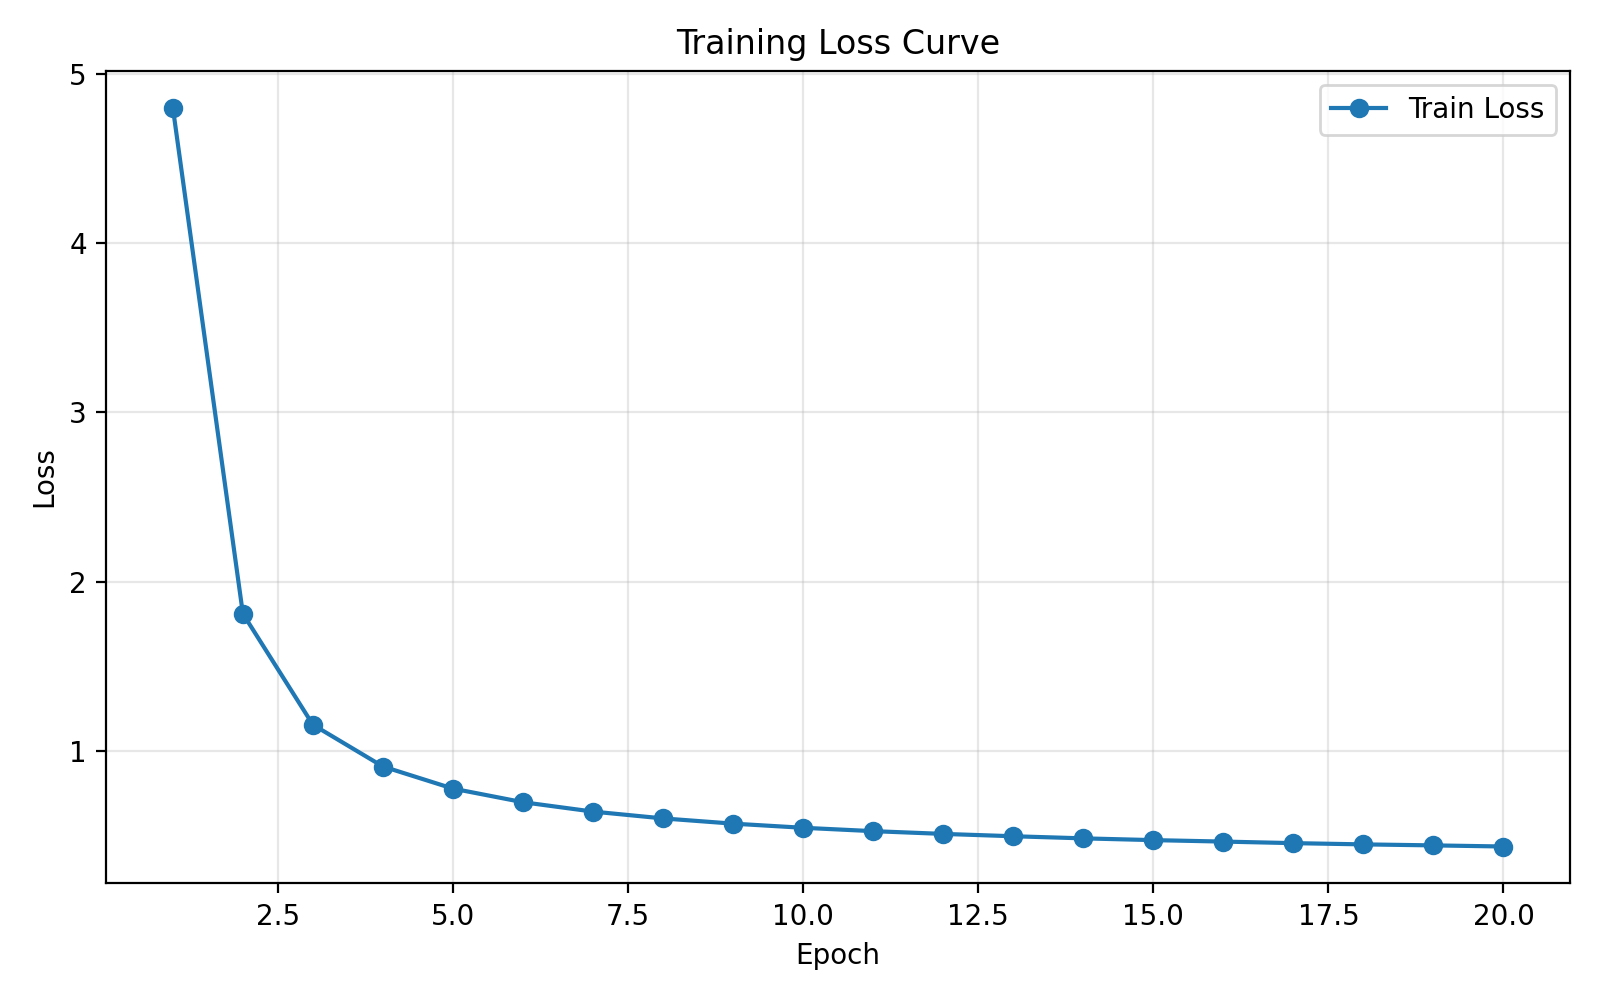

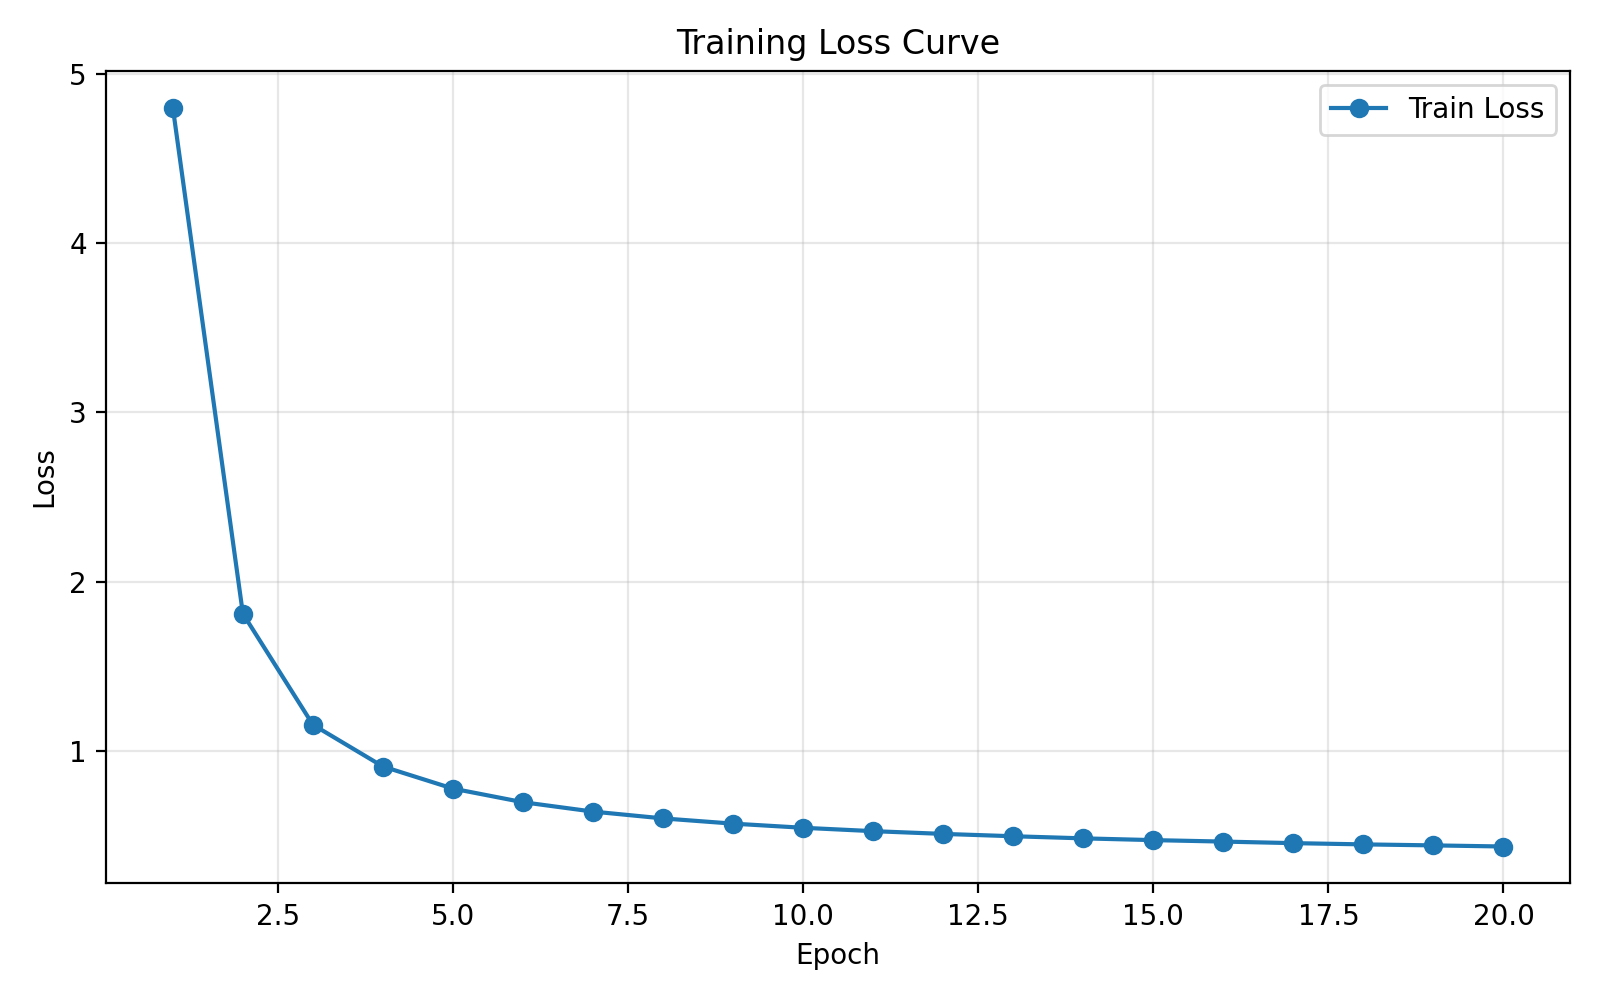27c31.png)贯”的情况。

### 4.2 生成效果分析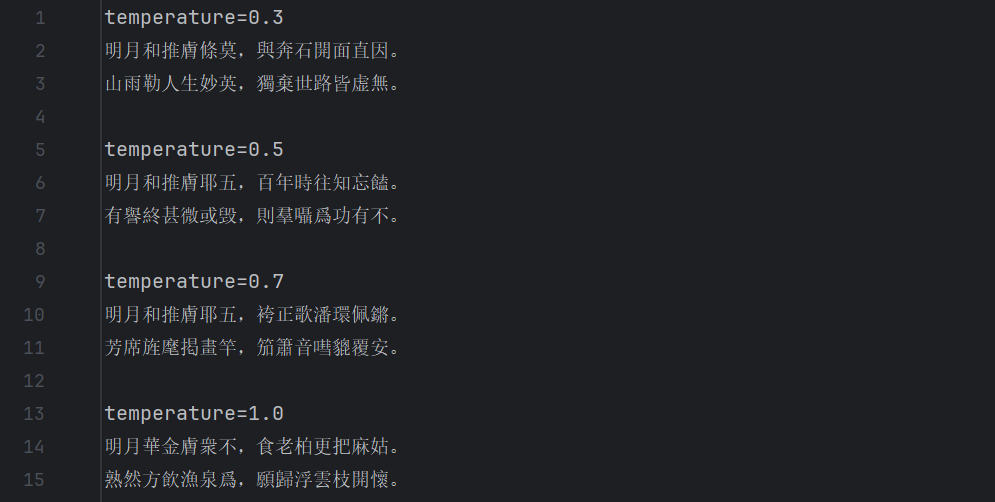


从生成结果可以看出，加入约束后，模型输出在形式上更加
首先，叠字约束减少了无意义重复。字符级语言模型在采样时容易出现连续重复字符，尤其是在模型不确定下一个字时，可能反复采样到高频字。叠字位置约束可以避免第 1-2、2-3、4-5、5-6 等位置出现不自然重复，只允许第 3-4 和第 6-7 个字出现叠字，使重复字符更像有意使用的修

其次，押韵约束增强了有明显联系；加入押韵约束后，第四句末字会从与第二句末字同韵或近韵的候选字中选择，因可能此生成结果更符合传统绝句中偶数句押韵的形式要求。

不过，约束方法也存在一定缺点。由于押韵和叠字约束是在生成阶段强制施加的，模型有时会被迫选择概率不是最高的字，导致局部的语义理解能力。

## 4.3 存在的问题与改进方向

虽然本实验能够生成固定格式的古诗，并加入了一定的形式约束，但仍然存在以下不足。

1、语义连贯性仍然有限

本实验采用的是字符级 LSTM 语言模型，模型主要学习局部字符之间的统计关系。虽然它能够生成具有古诗风格的字词组合，但并不真正理解整首诗的主题、意境和逻辑关系。因此生成结果可能出现局部像诗、整体含义不够连贯。

2、押韵规则仍然较简单

本实验使用现代汉语拼音韵母进行押韵判断，并将 `an / ian / uan / van` 等近似韵母归并为同一韵部。这种方法实现简单，但并不等同于严格的古典诗词格律。古诗押韵通常应参考平水韵或中华新韵，后续可以加入模3句格式。

3、可以尝试 Transformer 模型

RNN/LSTM 在序列建模中具有较好的教育意义和可解释性，但其长距离依赖建模能力有限。后续ormer Decoder-only 结构进行古诗生成。Transformer 通过自注意力机制能够更好地捕捉长距离依赖，可能提升生成结果的整体连贯性。成结果的整体连贯性。

## 5 总结

本实验完成了基于 RNN/LSTM 的古诗生成任务，实现了从数据预处理、模型构建、模型训练到文本生成的完整流程。实验结果表明，LSTM 能够学习到一定的古诗字符搭配规律，并生成具有古诗形式的文本。但由于字符级模型的语义建模能力有限，生成结果在整体意境和逻辑连贯性方面仍有提升空间。后续可以通过扩充数据集、引入更严格的韵律规则、改进采样策略或采用 Transformer 模型进一步提高古诗生成质量。